# **TP Bonus - Decision trees and random forests - Classification of drinkers based on body signals**

October 2025

BAQUE Vincent - BECKER Axel - TRINQUANT Raphaël

**Abstract** : This notebook aims to establish a classification of drinker based on signal body,
using decision trees and random forests methods and comparing their performances.  
We use a dataset from National Health Insurance Service in Korea.


# Problem I : Random decision tree

## 1. Exploratory analysis of the database

In [1]:
# install libraries
import pandas as pd
import seaborn as sns
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, auc, mean_squared_error, roc_curve

### Explore quantitative variable

In [2]:
df = pd.read_csv('10 driking_dataset.csv', sep=';')
display(df.head())

,sex,age,height,weight,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,Class
0,Male,35,170,75,90.0,120.0,80.0,99.0,193.0,48.0,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,Y
1,Male,30,180,80,89.0,130.0,82.0,106.0,228.0,55.0,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,N
2,Male,40,165,75,91.0,120.0,70.0,98.0,136.0,41.0,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,N
3,Male,50,175,80,91.0,145.0,87.0,95.0,201.0,76.0,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,N
4,Male,50,165,60,80.0,138.0,82.0,101.0,199.0,61.0,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,N


Display the data types of the DataFrame.



In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sex               1400 non-null   object 
 1   age               1400 non-null   int64  
 2   height            1400 non-null   int64  
 3   weight            1400 non-null   int64  
 4   waistline         1400 non-null   float64
 5   SBP               1400 non-null   float64
 6   DBP               1400 non-null   float64
 7   BLDS              1400 non-null   float64
 8   tot_chole         1400 non-null   float64
 9   HDL_chole         1400 non-null   float64
 10  LDL_chole         1400 non-null   float64
 11  triglyceride      1400 non-null   float64
 12  hemoglobin        1400 non-null   float64
 13  urine_protein     1400 non-null   float64
 14  serum_creatinine  1400 non-null   float64
 15  SGOT_AST          1400 non-null   float64
 16  SGOT_ALT          1400 non-null   float64


Here is a quick description of each column:

sex: Gender of the individual (Male/Female).

age: Age in years.

height: Height in centimeters.

weight: Weight in kilograms.

waistline: Waist circumference in centimeters.

SBP: Systolic Blood Pressure, the top number in a blood pressure reading.

DBP: Diastolic Blood Pressure, the bottom number in a blood pressure reading.

BLDS: Fasting Blood Sugar (Blood Glucose Level).

tot_chole: Total Cholesterol level in the blood.

HDL_chole: High-Density Lipoprotein ("good cholesterol") level.

LDL_chole: Low-Density Lipoprotein ("bad cholesterol") level.

triglyceride: A type of fat found in the blood.

hemoglobin: A protein in red blood cells that carries oxygen.

urine_protein: Presence of protein in the urine, an indicator of kidney function.

serum_creatinine: A waste product in the blood, indicating kidney function.

SGOT_AST: A liver enzyme (Aspartate Aminotransferase).

SGOT_ALT: A liver enzyme (Alanine Aminotransferase).

gamma_GTP: A liver enzyme (Gamma-Glutamyl Transferase), sensitive to alcohol.

Class: The target variable, indicating if the person is a drinker or not.

Show summary statistics for numerical columns.


In [4]:
display(df.describe())

,age,height,weight,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,46.896429,162.532143,63.514286,81.192429,122.452857,75.987857,100.244286,195.112857,56.663571,113.022143,131.211429,14.273143,1.087857,0.861071,25.580714,25.404286,37.462857
std,14.211211,9.299963,12.520454,9.758189,14.805600,10.123568,24.512698,37.298845,14.859132,33.895082,92.538026,1.570663,0.426259,0.255586,14.617126,19.989940,54.037184
min,20.000000,135.000000,35.000000,54.000000,84.000000,51.000000,61.000000,90.000000,22.000000,25.000000,16.000000,7.200000,1.000000,0.200000,4.000000,5.000000,3.000000
25%,35.000000,155.000000,55.000000,74.000000,111.000000,70.000000,87.000000,169.000000,46.000000,89.000000,71.000000,13.200000,1.000000,0.700000,19.000000,15.000000,15.000000
50%,45.000000,165.000000,65.000000,81.000000,120.000000,76.000000,96.000000,194.000000,54.000000,112.000000,105.000000,14.400000,1.000000,0.900000,23.000000,20.000000,23.000000
75%,55.000000,170.000000,70.000000,87.100000,132.000000,82.000000,105.000000,218.000000,65.000000,135.000000,163.250000,15.500000,1.000000,1.000000,28.000000,30.000000,40.000000
max,85.000000,185.000000,120.000000,118.400000,195.000000,120.000000,425.000000,384.000000,120.000000,325.000000,1027.000000,18.400000,5.000000,5.000000,278.000000,311.000000,871.000000


histograms or density plots for numerical features to visualize their distributions

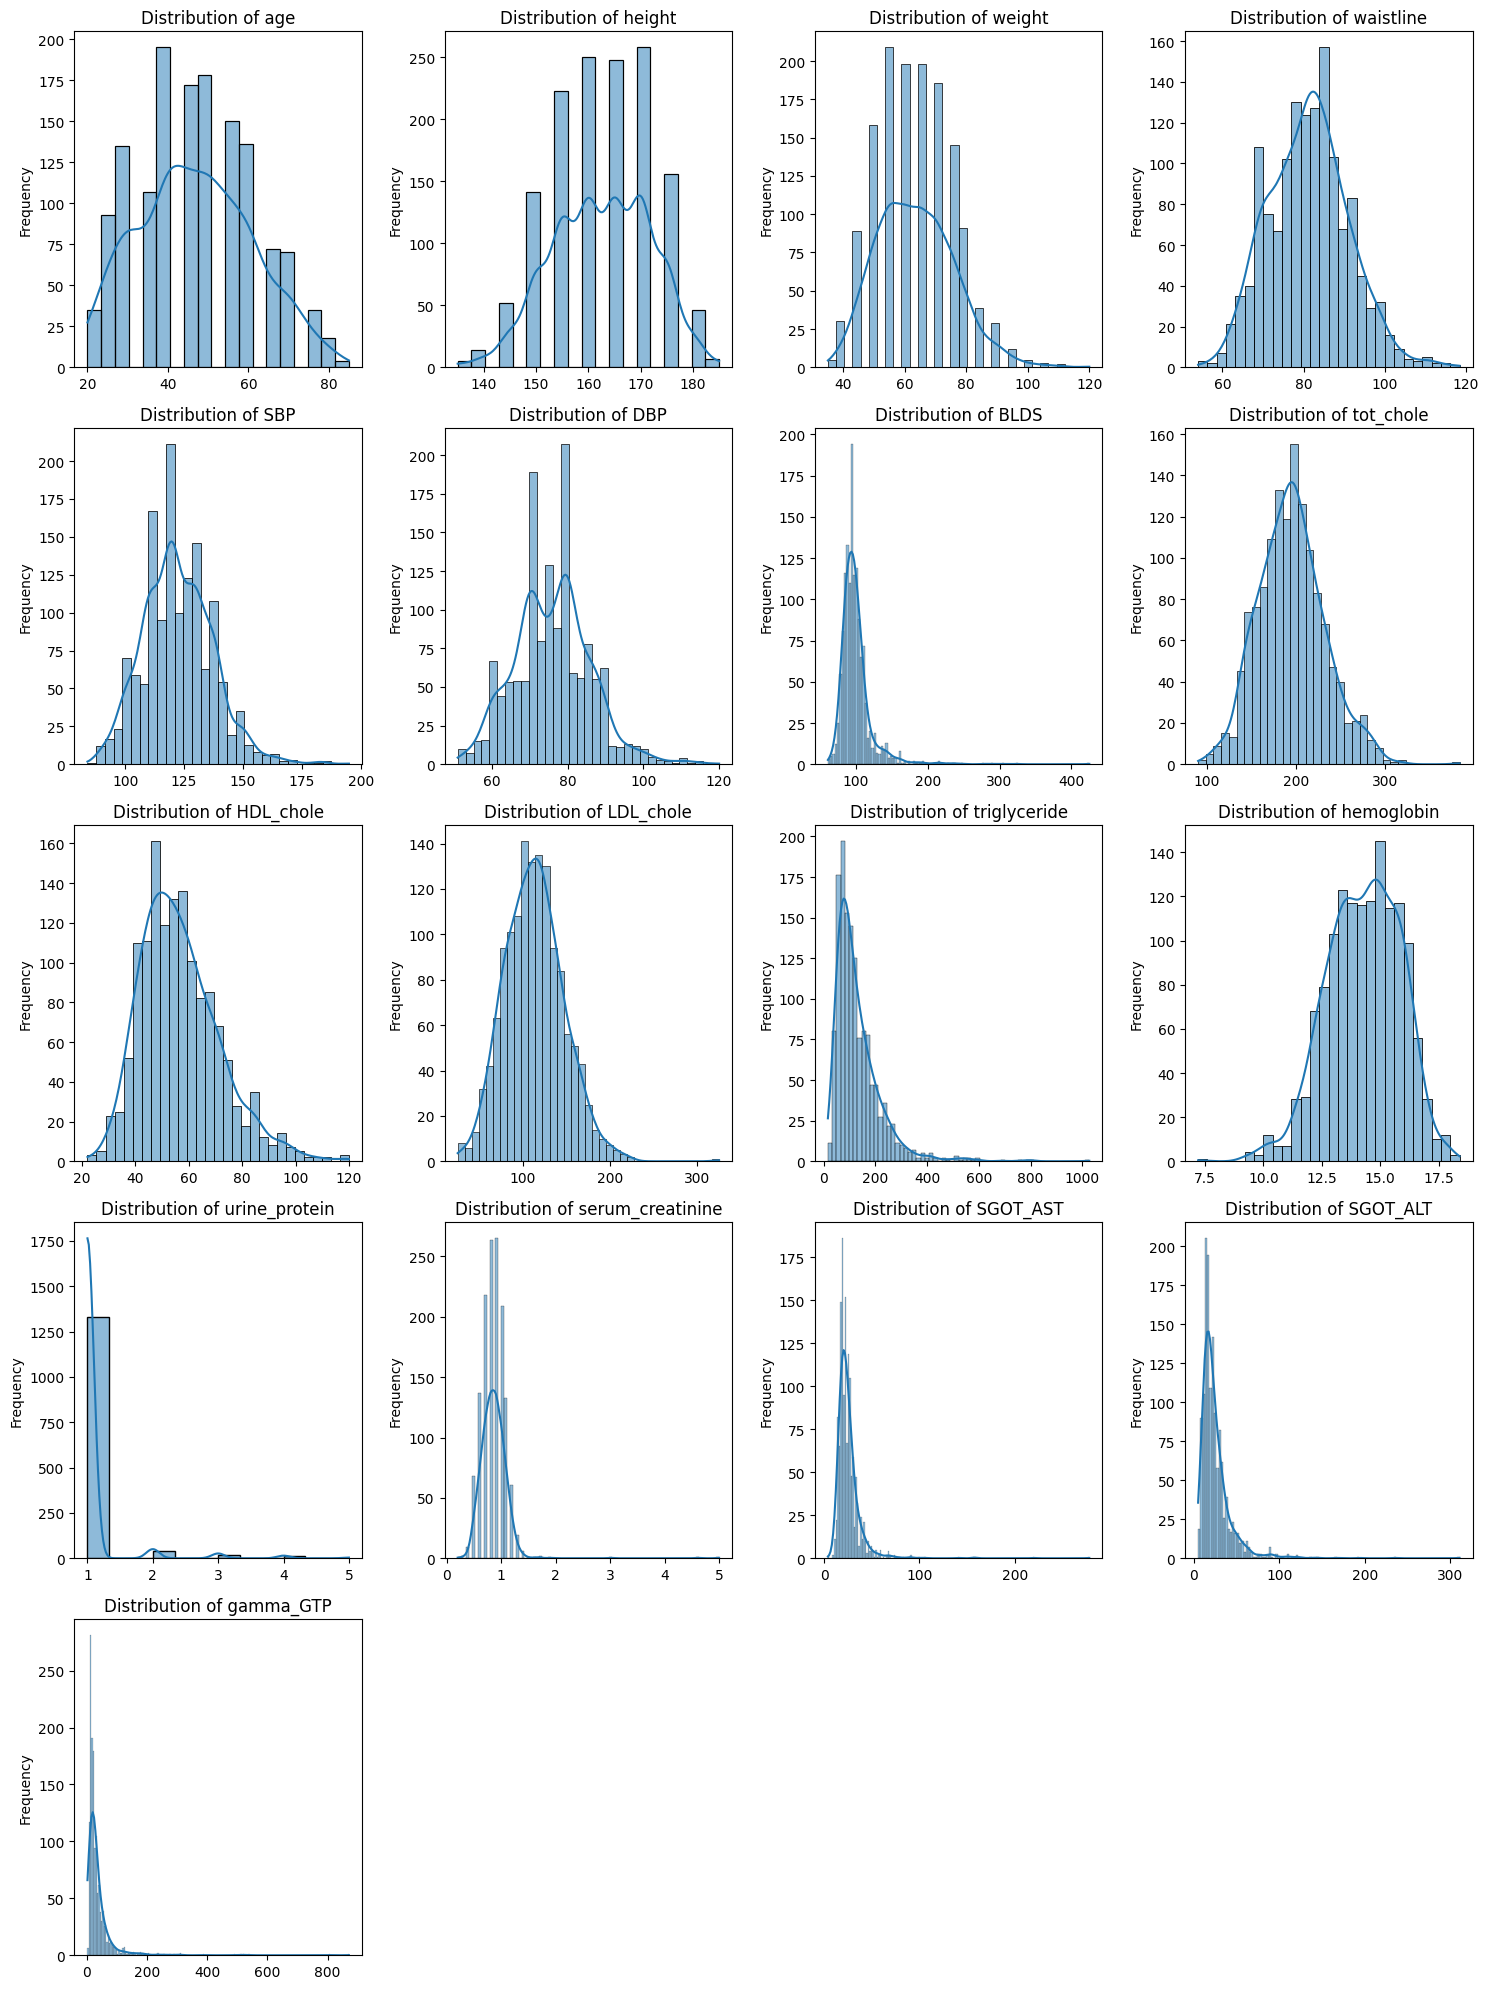

In [5]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols = len(numerical_cols)

if n_cols > 0:
    
    plots_per_row = 4
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    
    axes = axes.flatten()
    for i, col in enumerate(numerical_cols):
        ax = axes[i]  
        sns.histplot(data=df, x=col, kde=True, ax=ax)
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel('') 
        ax.set_ylabel('Frequency')

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")



We can see that most of the variables have a distribution that approach a normal distribution.

Generate boxplots for each numerical column to visualize the distribution and identify potential outliers.



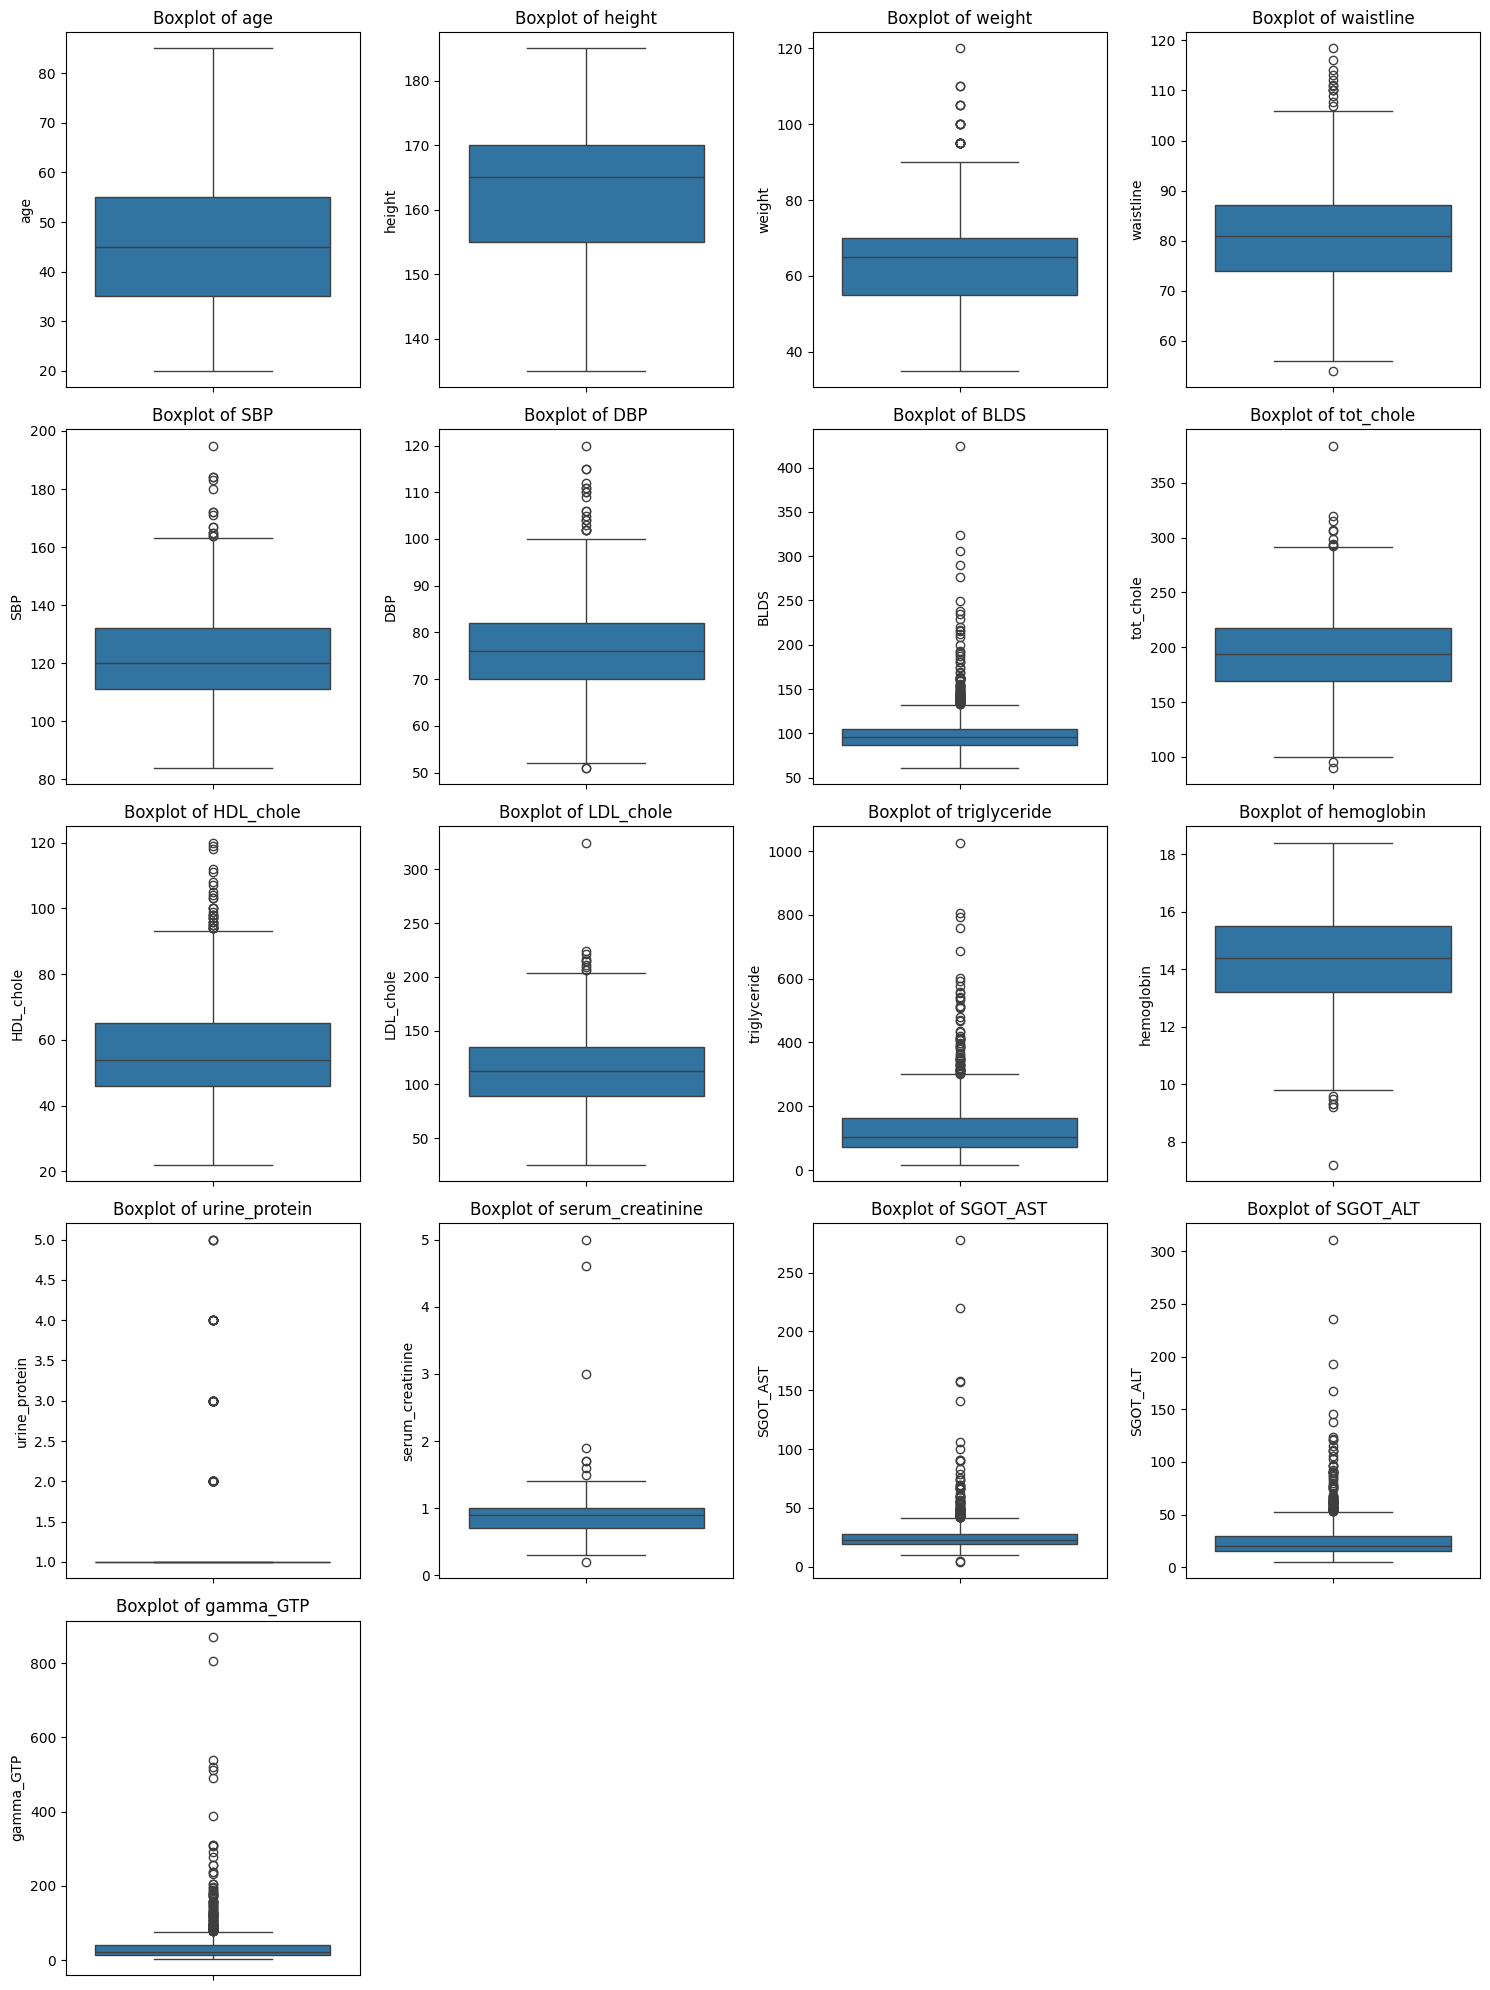

In [6]:
if n_cols > 0:
    
    plots_per_row = 4
    n_rows = math.ceil(n_cols / plots_per_row)
    fig, axes = plt.subplots(nrows=n_rows, ncols=plots_per_row, figsize=(15, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        ax = axes[i] 
        sns.boxplot(data=df, y=col, ax=ax)
        ax.set_title(f'Boxplot of {col}')
        ax.set_ylabel(col)
        ax.set_xlabel('') 

    for i in range(n_cols, len(axes)):
        axes[i].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found in the DataFrame.")

These box-plots confirm the presence of numerous outliers. It can potentially decrease the peformances of the models.

Text(0.5, 1.0, 'Correlation Matrix')

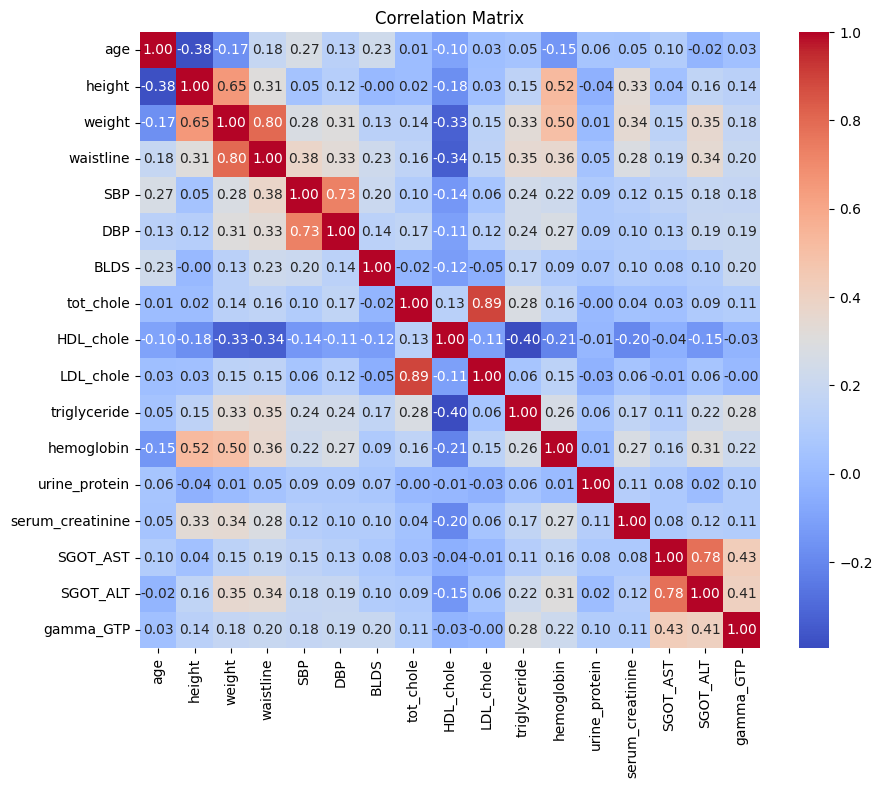

In [7]:
mat_corr = df.select_dtypes(include=['float64', 'int64']).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(mat_corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')

As expected, we observed strong positive correlation between height and weight, and between SGOT_AST and SGOT_ALT.

### Explore categorical variable


Examine the distribution of the 'sex' and 'Class' columns.


Distribution of Sex:
sex
Male      764
Female    636
Name: count, dtype: int64

Distribution of Class:
Class
Y    720
N    680
Name: count, dtype: int64


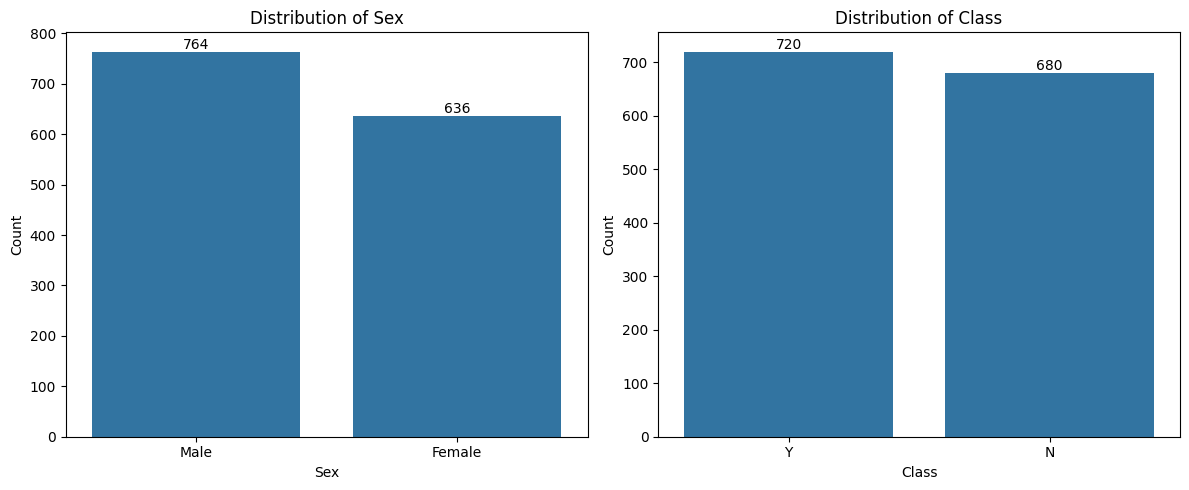

In [8]:
# Display value counts for sex and Class
print("Distribution of Sex:")
print(df['sex'].value_counts())
print("\nDistribution of Class:")
print(df['Class'].value_counts())

# Create bar plots for sex and class distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot sex distribution
sns.countplot(data=df, x='sex', ax=ax1)
ax1.set_title('Distribution of Sex')
ax1.set_xlabel('Sex')
ax1.set_ylabel('Count')

# Add count labels on the bars
for i in ax1.containers:
     ax1.bar_label(i)

# Plot class distribution
sns.countplot(data=df, x='Class', ax=ax2)
ax2.set_title('Distribution of Class')
ax2.set_xlabel('Class')
ax2.set_ylabel('Count')

# Add count labels on the bars
for i in ax2.containers:
     ax2.bar_label(i)

plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

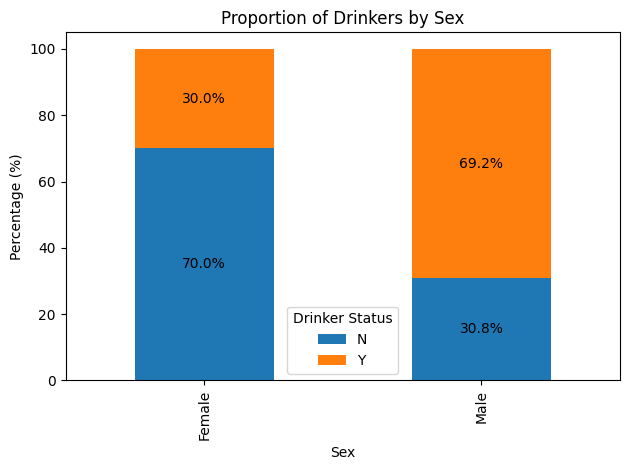

In [9]:
# Create a figure to display the proportions by sex
plt.figure(figsize=(10, 6))

# Use crosstab to create a contingency table
prop_data = pd.crosstab(df['sex'], df['Class'], normalize='index') * 100

# Create a bar plot
ax = prop_data.plot(kind='bar', stacked=True)

# Customize the plot
plt.title('Proportion of Drinkers by Sex')
plt.xlabel('Sex')
plt.ylabel('Percentage (%)')
plt.legend(title='Drinker Status')

# Add percentage labels on the bars
for c in ax.containers:
     ax.bar_label(c, fmt='%.1f%%', label_type='center')

plt.tight_layout()
plt.show()

This graphic give us the idea to make a baseline model, uniquely sexe-based.

Sex-based model (predict by P(Y|sex) > 0.5) metrics:
Accuracy   : 0.6957
Precision  : 0.6924
Sensitivity: 0.7347
Specificity: 0.6544
F1-score   : 0.7129
ROC AUC    : 0.6946
RMSE       : 0.5516

Confusion Matrix (rows=true, cols=pred):
[[445 235]
 [191 529]]

Classification Report:
              precision    recall  f1-score   support

       False       0.70      0.65      0.68       680
        True       0.69      0.73      0.71       720

    accuracy                           0.70      1400
   macro avg       0.70      0.69      0.69      1400
weighted avg       0.70      0.70      0.70      1400



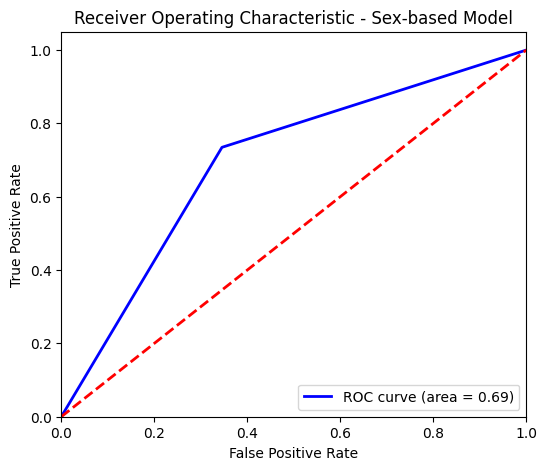

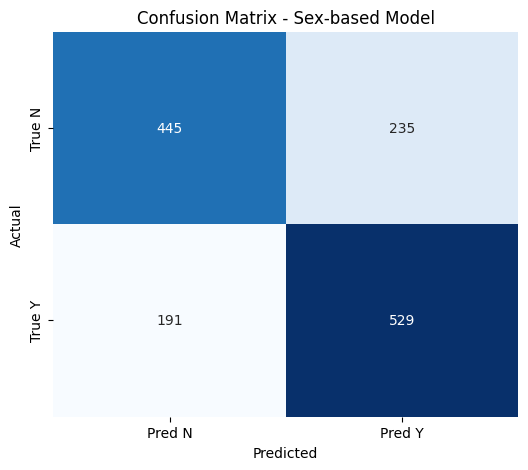


P(Y | sex) used for prediction:
sex
Female    0.300314
Male      0.692408
Name: Y, dtype: float64


In [10]:
# Sex-based classifier evaluation (predict by P(Y | sex) > 0.5)
y_test = df['Class'].map({'Y': True, 'N': False})

# Ensure 'props' (P(Class | sex)) exists; compute from df if not present
# props will have columns ['N', 'Y'] with probabilities in [0, 1]
props = pd.crosstab(df['sex'], df['Class'], normalize='index')

# Get sex for test samples (indices align with y_test)
sex_test = df.loc[y_test.index, 'sex']

# Use the conditional probability P(Y | sex) from props; map each test sample to its P(Y | sex)
sex_prob_Y = sex_test.map(lambda s: props.loc[s, 'Y']).astype(float)

# Predictions: predict True (drinker) if P(Y|sex) > 0.5
y_pred_sex = sex_prob_Y > 0.5

# Compute metrics
acc_sex = accuracy_score(y_test, y_pred_sex)
prec_sex = precision_score(y_test, y_pred_sex)
recall_sex = recall_score(y_test, y_pred_sex)  
f1_sex = f1_score(y_test, y_pred_sex)
cm = confusion_matrix(y_test, y_pred_sex)
specificity_sex = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else np.nan
roc_auc_sex = roc_auc_score(y_test, sex_prob_Y)  # use P(Y|sex) as score
rmse_sex = np.sqrt(mean_squared_error(y_test, y_pred_sex))


# Print results
print("Sex-based model (predict by P(Y|sex) > 0.5) metrics:")
print(f"Accuracy   : {acc_sex:.4f}")
print(f"Precision  : {prec_sex:.4f}")
print(f"Sensitivity: {recall_sex:.4f}")
print(f"Specificity: {specificity_sex:.4f}")
print(f"F1-score   : {f1_sex:.4f}")
print(f"ROC AUC    : {roc_auc_sex:.4f}")
print(f"RMSE       : {rmse_sex:.4f}")
print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sex))

# Plot ROC curve
plt.figure(figsize=(6,5))
fpr_sex, tpr_sex, thresholds = roc_curve(y_test, sex_prob_Y)
roc_auc_sex = auc(fpr_sex, tpr_sex)
plt.plot(fpr_sex, tpr_sex, color='blue', lw=2, label='ROC curve (area = %0.2f)' % roc_auc_sex)
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Sex-based Model')
plt.legend(loc="lower right")
plt.show()

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
               xticklabels=['Pred N', 'Pred Y'], yticklabels=['True N', 'True Y'])
plt.title('Confusion Matrix - Sex-based Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Optional: show sex-wise probabilities used
print("\nP(Y | sex) used for prediction:")
print(props['Y'])

The baseline "sec-based" model is significantly better than chance, with an acurracy of 69.57%.

### Summary:

#### Data Analysis Key Findings

*   The dataset contains 19 columns with a mix of data types, including `object`, `int64`, and `float64`.
*   There are no missing values in any of the columns.
*   Descriptive statistics for numerical columns were generated, providing summary metrics such as mean, standard deviation, minimum, and maximum values.
*   Histograms and density plots were created for numerical features, visualizing their distributions.
*   Boxplots were generated for numerical features to identify potential outliers.
*   The 'sex' column has two categories: 'Male' (764 instances) and 'Female' (636 instances).
*   The 'Class' column has two categories: 'Y' (720 instances) and 'N' (680 instances).
*   Countplots visually confirmed the distributions of 'sex' and 'Class'.

#### Insights or Next Steps

*   Further analysis could involve investigating the potential outliers identified in the boxplots and deciding on an appropriate strategy for handling them.
*   Exploring the relationships between the categorical variables ('sex' and 'Class') and the numerical features could provide deeper insights into the dataset.


## 2. Build a classifier with a decision tree


#### Data preparation
Prepare the data for the decision tree model, including encoding categorical variables and splitting the data into training and testing sets.


In [11]:
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df_encoded.drop('Class_Y', axis=1)
y = df_encoded['Class_Y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

display(X_train.head())
display(y_train.head())

,age,height,weight,waistline,SBP,DBP,BLDS,tot_chole,HDL_chole,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,sex_Male
1121,30,165,50,62.0,110.0,60.0,78.0,145.0,51.0,88.0,32.0,13.1,2.0,0.8,20.0,18.0,11.0,True
48,45,155,65,90.0,132.0,80.0,104.0,215.0,55.0,143.0,81.0,11.8,1.0,0.7,16.0,12.0,17.0,False
155,45,175,70,79.0,137.0,84.0,90.0,196.0,85.0,103.0,53.0,15.9,1.0,1.2,42.0,23.0,13.0,True
306,45,175,65,84.0,100.0,60.0,93.0,186.0,51.0,103.0,163.0,14.5,1.0,1.1,24.0,23.0,18.0,True
1287,25,150,75,90.0,124.0,70.0,104.0,199.0,62.0,121.0,78.0,11.6,1.0,0.7,13.0,16.0,32.0,False


1121     True
48      False
155      True
306      True
1287     True
Name: Class_Y, dtype: bool

#### Initial model training
Train an initial decision tree model on the training data.


In [12]:
dt_classifier = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)

# Calculate metrics
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
sensitivity_dt = recall_score(y_test, y_pred_dt)  # sensitivity
cm_dt = confusion_matrix(y_test, y_pred_dt)
specificity_dt = cm_dt[0,0] / (cm_dt[0,0] + cm_dt[0,1]) if (cm_dt[0,0] + cm_dt[0,1]) > 0 else np.nan
f1_dt = f1_score(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
auc_score_dt = roc_auc_score(y_test, dt_classifier.predict_proba(X_test)[:,1])  # renamed to avoid conflict



print(f"Decision Tree Classifier Accuracy: {accuracy_dt:.4f}")
print(f"Decision Tree Classifier Precision: {precision_dt:.4f}")
print(f"Decision Tree Classifier Sensitivity: {sensitivity_dt:.4f}")
print(f"Decision Tree Classifier Specificity: {specificity_dt:.4f}")
print(f"Decision Tree Classifier F1 Score: {f1_dt:.4f}")
print(f"Decision Tree Classifier RMSE: {rmse_dt:.4f}")
print(f"Decision Tree Classifier ROC AUC: {auc_score_dt:.4f}")

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm_dt)


Decision Tree Classifier Accuracy: 0.7607
Decision Tree Classifier Precision: 0.7333
Decision Tree Classifier Sensitivity: 0.8403
Decision Tree Classifier Specificity: 0.6765
Decision Tree Classifier F1 Score: 0.7832
Decision Tree Classifier RMSE: 0.4892
Decision Tree Classifier ROC AUC: 0.8280

Confusion Matrix (rows=true, cols=pred):
[[ 92  44]
 [ 23 121]]


#### Hyperparameter tuning (cross-validation)

Use cross-validation to find the optimal hyperparameters for the decision tree model.


In [13]:
param_grid = {
    'max_depth': [None, 3, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=dt_classifier, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)
print("Best Estimator:", best_estimator)

Best Hyperparameters: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Estimator: DecisionTreeClassifier(max_depth=5, random_state=42)


#### Pruning (if applicable)

Apply pruning techniques to the decision tree to prevent overfitting.


In [14]:
optimized_dt_classifier = DecisionTreeClassifier(random_state=42, **best_params)
optimized_dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

#### Model evaluation

Evaluate the performance of the optimized decision tree model on the testing data by calculating and printing accuracy, precision, recall, and F1-score.


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import mean_squared_error

y_pred = optimized_dt_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
sensitivity = recall_score(y_test, y_pred)
specificity = confusion_matrix(y_test, y_pred)[0,0] / (confusion_matrix(y_test, y_pred)[0,0] + confusion_matrix(y_test, y_pred)[0,1])
f1 = f1_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred)
auc = roc_auc_score(y_test, optimized_dt_classifier.predict_proba(X_test)[:,1])


print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"AUC: {auc:.4f}")


Accuracy: 0.7000
Precision: 0.7027
Sensitivity: 0.7222
Specificity: 0.6765
F1-score: 0.7123
RMSE: 0.3000
AUC: 0.7699


In [16]:
comparison_df = pd.DataFrame({
     'Non-Optimized': [accuracy_dt, precision_dt, sensitivity_dt, specificity_dt, f1_dt, auc_score_dt, rmse_dt],
     'Optimized': [accuracy, precision, sensitivity, specificity, f1, auc, rmse]
}, index=['Accuracy', 'Precision', 'Sensitivity', 'Specificity', 'F1-score', 'ROC AUC', 'RMSE'])

display(comparison_df.round(4))


,Non-Optimized,Optimized
Accuracy,0.7607,0.7000
Precision,0.7333,0.7027
Sensitivity,0.8403,0.7222
Specificity,0.6765,0.6765
F1-score,0.7832,0.7123
ROC AUC,0.8280,0.7699
RMSE,0.4892,0.3000


Based on almost every standard classification metric, the Non-Optimized Decision Tree is the superior model. It has higher accuracy, precision, recall (sensitivity), F1-score, and a better ability to distinguish between classes (ROC AUC).

However, the Optimized model has a significantly better (lower) RMSE, which is a measure of error. In the following parts, we will continue to use the Non-Optimized Decision Tree.

#### Model visualization

Visualize the optimized decision tree.


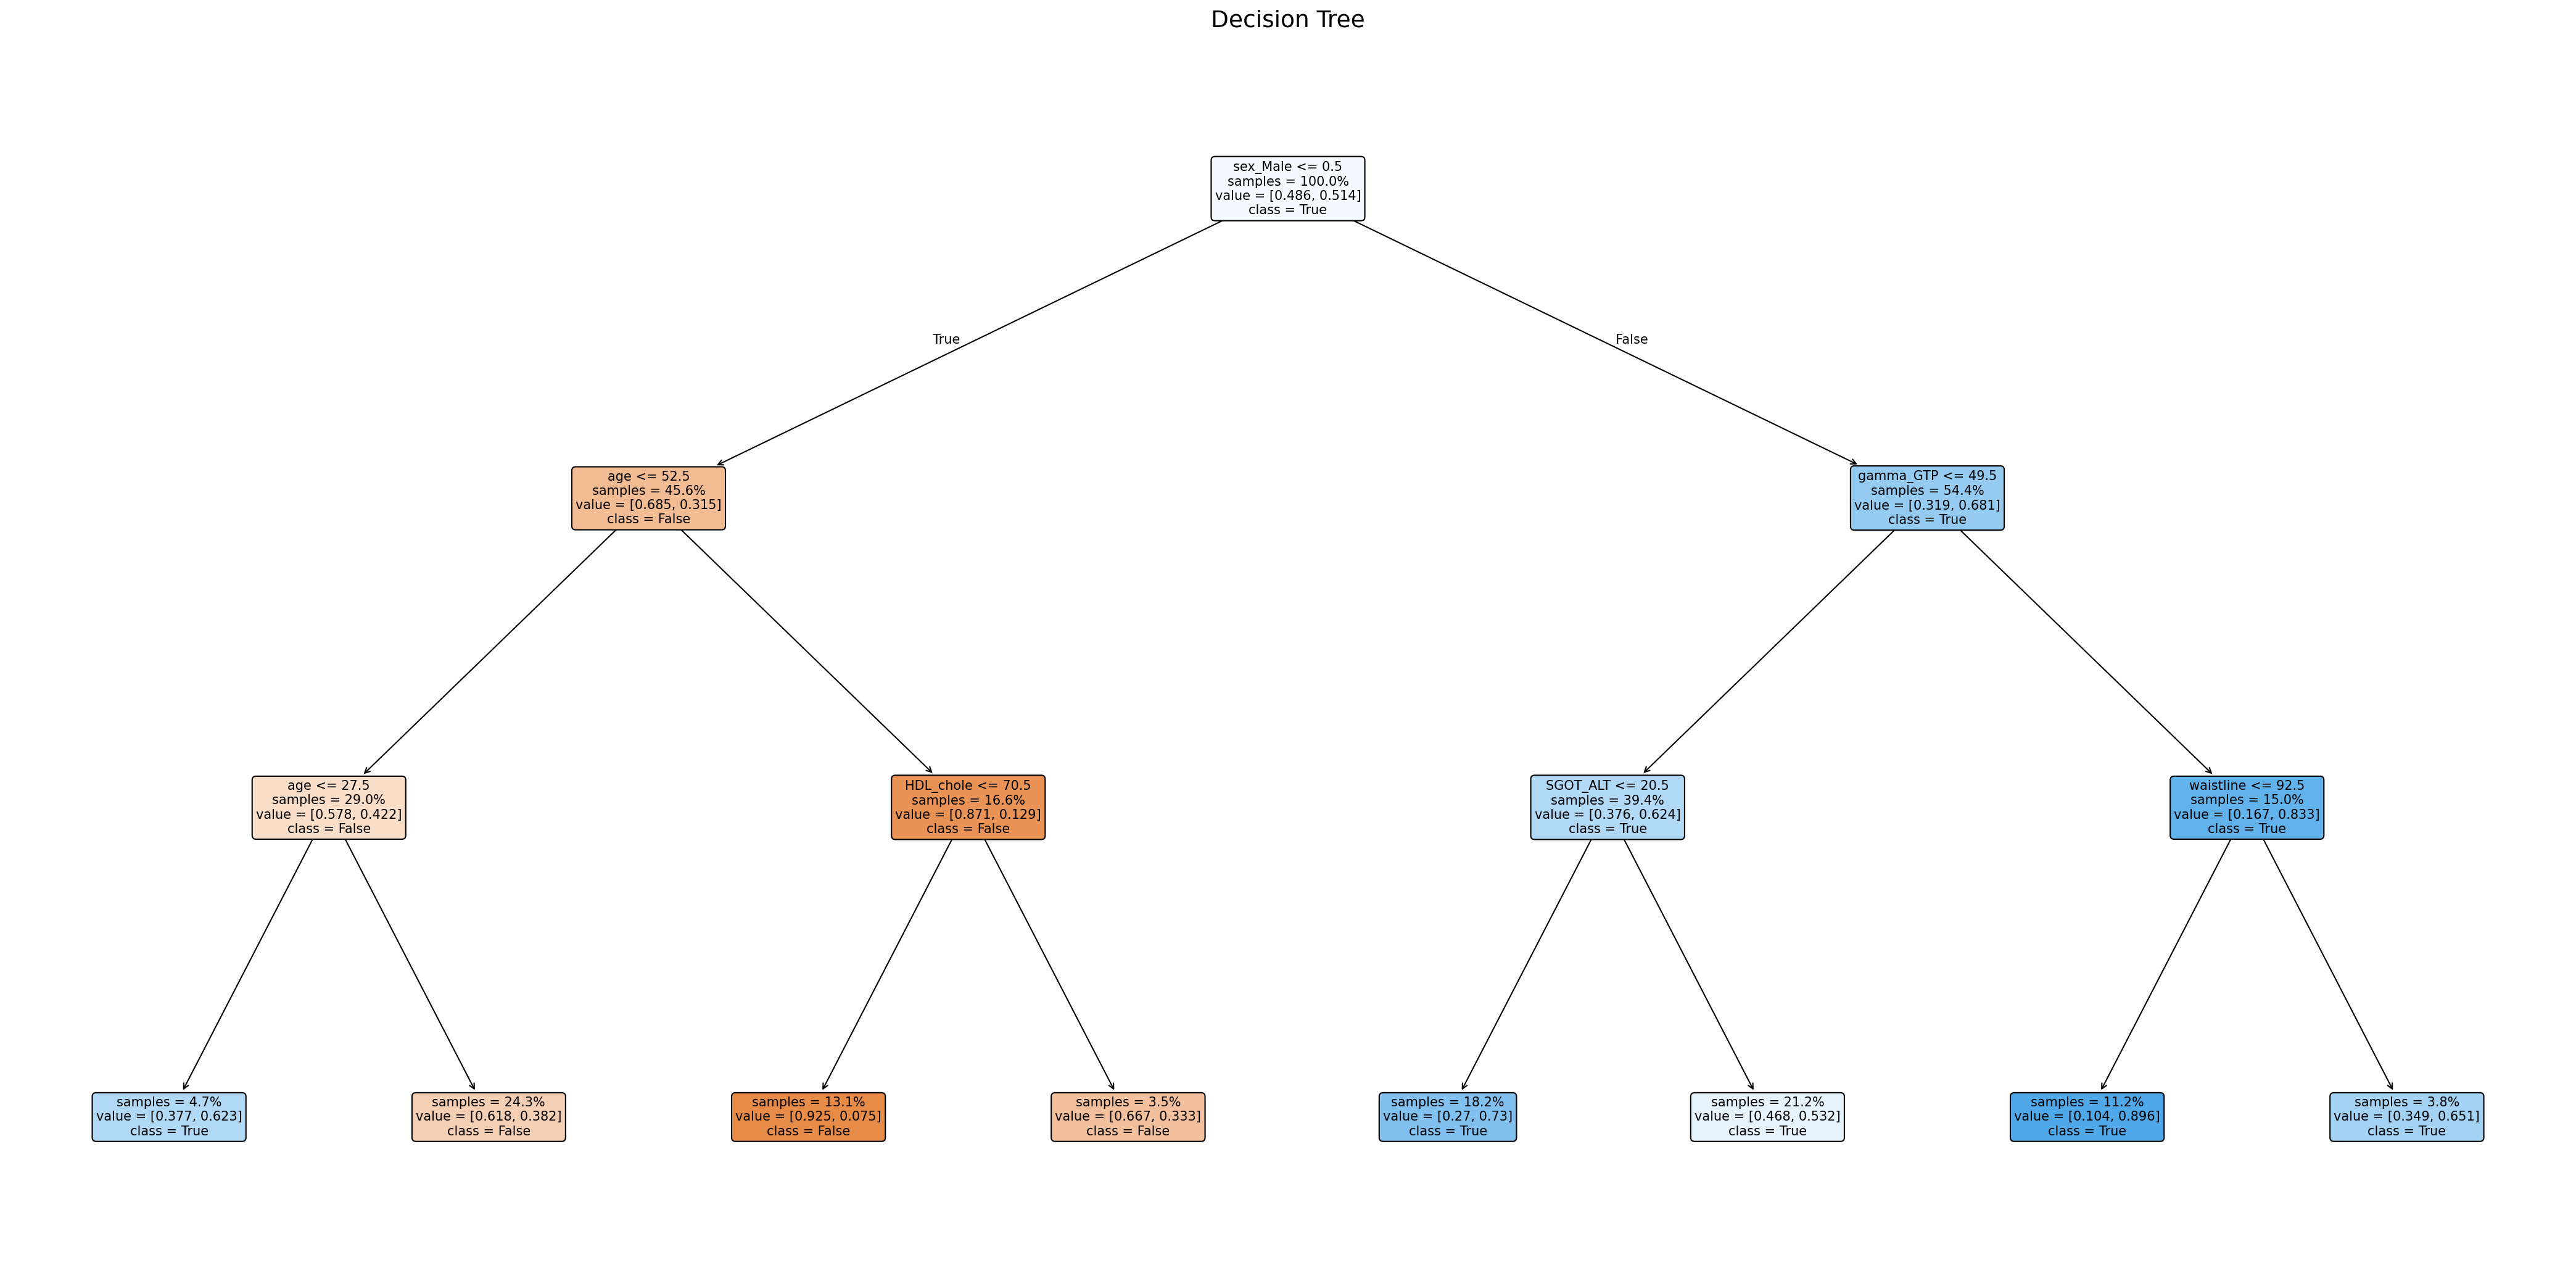

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt



# Improve readability: larger figure, higher dpi, bigger fonts, rounded nodes and proportions
plt.rcParams.update({'font.size': 12})
fig, ax = plt.subplots(figsize=(28, 14), dpi=150)

class_names = [str(c) for c in dt_classifier.classes_]
plot_tree(
     dt_classifier,
     filled=True,
     rounded=True,
     feature_names=X.columns,
     class_names=class_names,
     proportion=True,
     impurity=False,
     fontsize=10,
     ax=ax
)

plt.title("Decision Tree", fontsize=18)
plt.tight_layout()


# Show the plot
plt.show()

## 3. Detailed Model Evaluation

Let's delve deeper into the model's performance by examining metrics for each class and visualizing the confusion matrix and the ROC curve.

Classification Report:
              precision    recall  f1-score   support

       False       0.80      0.68      0.73       136
        True       0.73      0.84      0.78       144

    accuracy                           0.76       280
   macro avg       0.77      0.76      0.76       280
weighted avg       0.77      0.76      0.76       280



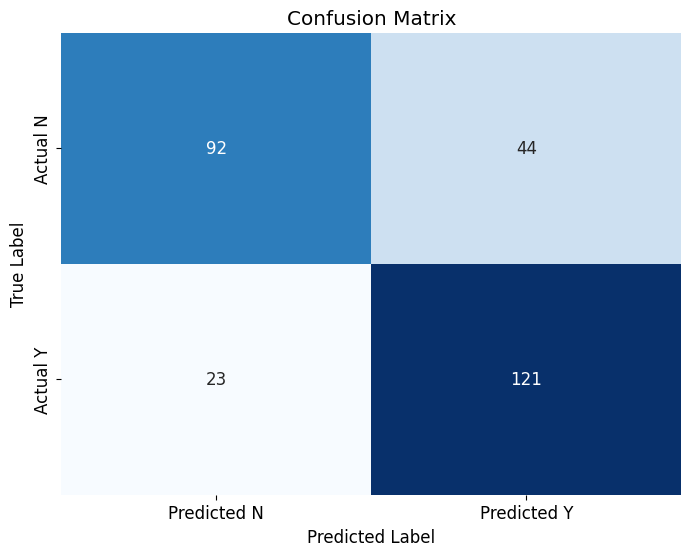

In [18]:
# Classification Report (includes precision, recall, f1-score per class)
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

#### ROC Curve

Generate and display the Receiver Operating Characteristic (ROC) curve to evaluate the model's performance across different classification thresholds.

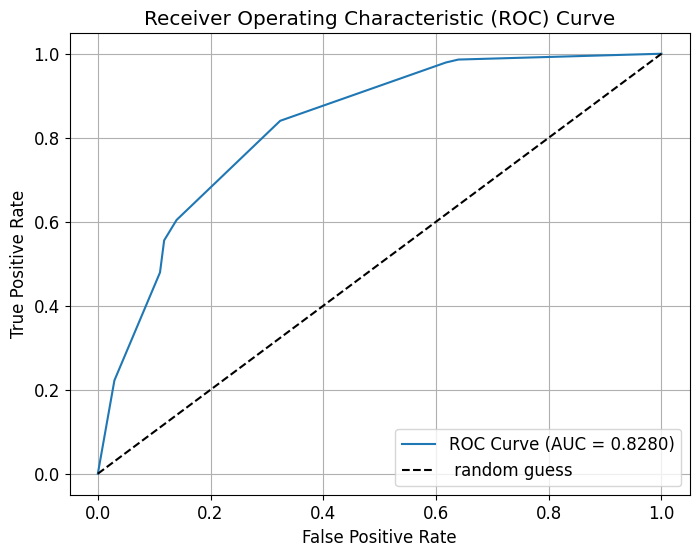

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get the predicted probabilities for the positive class (Class_Y = True)
y_prob = dt_classifier.predict_proba(X_test)[:, 1]

# Calculate the false positive rate (fpr) and true positive rate (tpr)
fpr_dt, tpr_dt, thresholds = roc_curve(y_test, y_prob)

# Calculate the Area Under the ROC Curve (AUC)
roc_auc_dt = roc_auc_score(y_test, y_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'ROC Curve (AUC = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

Detailed Analysis

- The AUC Value: The AUC is 0.82, wich indicates a model with good discrimination capability, which is much better than a random guess and our baseline-model.

- The Shape of the Curve: The blue curve is clearly above the diagonal line (which represents a random model). This visually confirms that the model has real predictive power. It manages to correctly identify positive cases (True Positive Rate) without drastically increasing the number of false positives (False Positive Rate).

- The Trade-off: The curve illustrates the trade-off the model makes. For example, you can read from the graph: At a False Positive Rate of about 0.2 (i.e., by accepting to misclassify 20% of "non-drinkers" as "drinkers"), the model achieves a True Positive Rate of over 0.7 (it correctly identifies more than 60% of the actual "drinkers").

In conclusion, this is not a perfect model, but it is quite useful and performs well. There is a good separation between the classes, which means the analyzed body signals are relevant for identifying drinkers.

## 4. Comparaison with a logistic regression model
Compare the performance of the optimal decision tree model with a classical logistic regression model on the test data, evaluating both models using detailed accuracy by class (precision, recall, F1-score), confusion matrix, and ROC AUC.

### Train a logistic regression model

Train a logistic regression model on the same training data used for the decision tree.


In [20]:
from sklearn.linear_model import LogisticRegression

lr_classifier = LogisticRegression(random_state=42, max_iter=10000)
lr_classifier.fit(X_train, y_train)

LogisticRegression(max_iter=10000, random_state=42)

### Evaluate the logistic regression model

Evaluate the performance of the logistic regression model on the test data using the same metrics as for the decision tree (accuracy, precision, recall, F1-score, confusion matrix, and ROC AUC).


Logistic Regression Accuracy: 0.7429
Logistic Regression Precision: 0.7500
Logistic Regression Sensitivity: 0.7500
Logistic Regression Specificity: 0.7353
Logistic Regression F1-score: 0.7500
Logistic Regression RMSE: 0.2571


c:\Users\rtrin\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


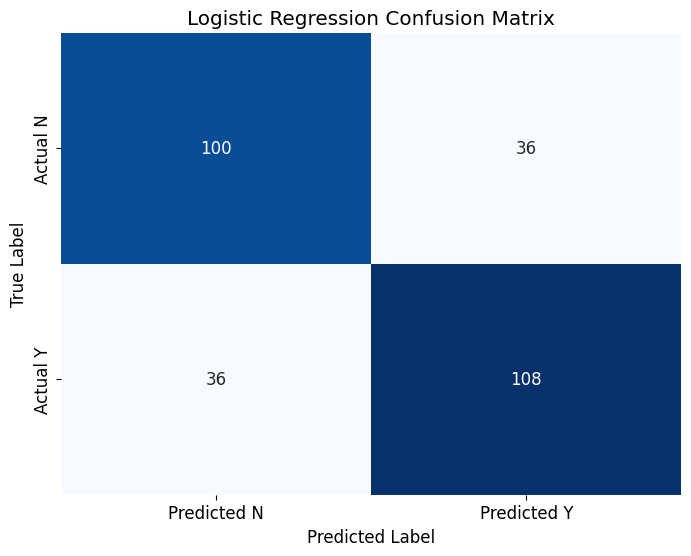

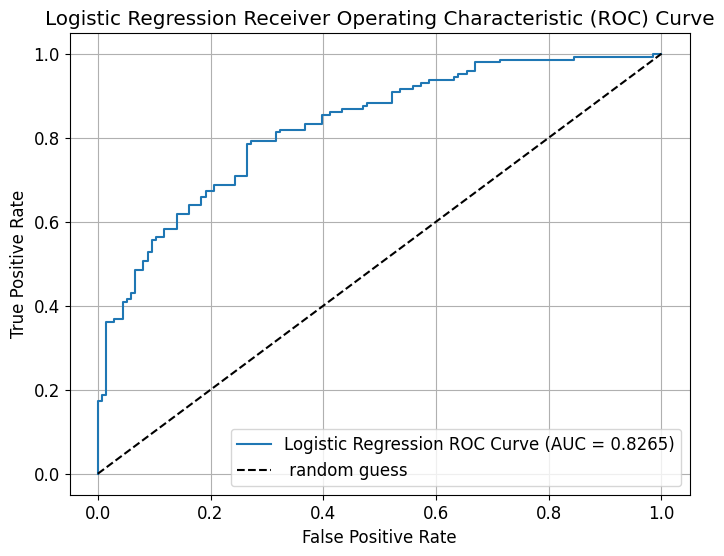

In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming lr_classifier is already trained
# If not, train it first:
lr_classifier = LogisticRegression(random_state=42, max_iter=1000)
lr_classifier.fit(X_train, y_train)

# Predict on the test data
y_pred_lr = lr_classifier.predict(X_test)

# Calculate evaluation metrics
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
sensitivity_lr = recall_score(y_test, y_pred_lr)
specificity_lr = confusion_matrix(y_test, y_pred_lr)[0,0] / (confusion_matrix(y_test, y_pred_lr)[0,0] + confusion_matrix(y_test, y_pred_lr)[0,1])
f1_lr = f1_score(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)


# Print evaluation metrics
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Precision: {precision_lr:.4f}")
print(f"Logistic Regression Sensitivity: {sensitivity_lr:.4f}")
print(f"Logistic Regression Specificity: {specificity_lr:.4f}")
print(f"Logistic Regression F1-score: {f1_lr:.4f}")
print(f"Logistic Regression RMSE: {rmse_lr:.4f}")

# Generate and plot confusion matrix
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted N', 'Predicted Y'], yticklabels=['Actual N', 'Actual Y'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Generate and plot ROC curve
y_prob_lr = lr_classifier.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression ROC Curve (AUC = {roc_auc_lr:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Compare model performance

Compare the evaluation metrics of the logistic regression model with those of the decision tree model and summarize the findings.


In [22]:
# Create a DataFrame for model comparison
comparison_data = {
     'Decision Tree': [
          accuracy_dt,
          precision_dt,
          sensitivity_dt,
          specificity_dt,
          f1_dt,
          auc_score_dt,
          rmse_dt
     ],
     'Logistic Regression': [
          accuracy_lr,
          precision_lr,
          sensitivity_lr,
          specificity_lr,
          f1_lr,
          roc_auc_lr,
          rmse_lr
     ]
}

# Define the index (metric names)
metrics_index = [
     'Accuracy',
     'Precision',
     'Sensitivity',
     'Specificity', 
     'F1-score',
     'ROC AUC',
     'RMSE'
]

# Create and display the comparison DataFrame
comparison_df = pd.DataFrame(comparison_data, index=metrics_index)
display(comparison_df.round(4))



,Decision Tree,Logistic Regression
Accuracy,0.7607,0.7429
Precision,0.7333,0.7500
Sensitivity,0.8403,0.7500
Specificity,0.6765,0.7353
F1-score,0.7832,0.7500
ROC AUC,0.8280,0.8265
RMSE,0.4892,0.2571


### Metric-by-Metric Interpretation

- **Accuracy (0.76 vs 0.74):** The Decision Tree is slightly better at classifying all samples correctly.

- **Precision (0.73 vs 0.75):** The Logistic Regression is better here. When it predicts a person is a drinker, it is correct 75% of the time, compared to 73% for the Decision Tree. This makes it a more "cautious" or reliable model when making a positive prediction.

- **Sensitivity (Recall) (0.84 vs 0.75):** This is the Decision Tree's biggest strength. It successfully identifies 84% of all the actual drinkers in the dataset. If the primary goal is to find as many drinkers as possible, even at the risk of misclassifying some non-drinkers, the Decision Tree is the superior choice.

- **Specificity (0.67 vs 0.73):** The Logistic Regression is significantly better at correctly identifying non-drinkers. This complements its higher precision.

- **F1-score (0.78 vs 0.75):** The Decision Tree has a higher F1-score, which indicates a better balance between its (very high) Recall and its (slightly lower) Precision.

- **RMSE (Root Mean Squared Error) (0.49 vs 0.26):** The Logistic Regression is a clear winner here. Its probability predictions are much closer to the actual binary outcomes (0 or 1). This suggests the probabilities generated by the Logistic Regression are more reliable and better calibrated than those from the Decision Tree.

In conclusion, the two models have very similar performance. The choice of the models will be made given the cost of finding a false positive or a false negative. It depends of the application.

# Problem II : Implementations of Random Forest

## 1. Comparaison of Scikit-learn RandomForestClassifier (RF) and Xgboost Random Forests (XG-RF)

In [23]:
# import libraries
from sklearn.model_selection import cross_val_score
import xgboost as xgb

# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf_classifier.fit(X_train, y_train)
xg_rf_classifier = xgb.XGBRFClassifier(n_estimators=100, random_state=42)
xg_rf_classifier.fit(X_train, y_train)

# Predict on the test data
y_pred_rf = rf_classifier.predict(X_test)
y_pred_xg_rf = xg_rf_classifier.predict(X_test)

In [24]:

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
sensitivity_rf = recall_score(y_test, y_pred_rf)
specificity_rf = confusion_matrix(y_test, y_pred_rf)[0,0] / (confusion_matrix(y_test, y_pred_rf)[0,0] + confusion_matrix(y_test, y_pred_rf)[0,1])
f1_rf = f1_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf)

accuracy_xg_rf = accuracy_score(y_test, y_pred_xg_rf)
precision_xg_rf = precision_score(y_test, y_pred_xg_rf)
sensitivity_xg_rf = recall_score(y_test, y_pred_xg_rf)
specificity_xg_rf = confusion_matrix(y_test, y_pred_xg_rf)[0,0] / (confusion_matrix(y_test, y_pred_xg_rf)[0,0] + confusion_matrix(y_test, y_pred_xg_rf)[0,1])
f1_xg_rf = f1_score(y_test, y_pred_xg_rf)
rmse_xg_rf = mean_squared_error(y_test, y_pred_xg_rf)

# Create a DataFrame for model comparison
comparison_data = {
     'Random Forest': [
          accuracy_rf,
          precision_rf,
          sensitivity_rf,
          specificity_rf,
          f1_rf,
          rmse_rf
     ],
     'XGBoost Random Forest': [
          accuracy_xg_rf,
          precision_xg_rf,
          sensitivity_xg_rf,
          specificity_xg_rf,
          f1_xg_rf,
          rmse_xg_rf
     ]
}

# Define the index (metric names)
metrics_index = [
     'Accuracy',
     'Precision', 
     'Sensitivity',
     'Specificity',
     'F1-score',
     'RMSE'
]

# Create and display the comparison DataFrame
comparison_df = pd.DataFrame(comparison_data, index=metrics_index)
display(comparison_df.round(4))

print("\nClassification Report of Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf))

print("\nClassification Report of XGBoost Random Forest Classifier:")
print(classification_report(y_test, y_pred_xg_rf))



,Random Forest,XGBoost Random Forest
Accuracy,0.7250,0.7357
Precision,0.7161,0.7273
Sensitivity,0.7708,0.7778
Specificity,0.6765,0.6912
F1-score,0.7425,0.7517
RMSE,0.2750,0.2643



Classification Report of Random Forest Classifier:
              precision    recall  f1-score   support

       False       0.74      0.68      0.70       136
        True       0.72      0.77      0.74       144

    accuracy                           0.72       280
   macro avg       0.73      0.72      0.72       280
weighted avg       0.73      0.72      0.72       280


Classification Report of XGBoost Random Forest Classifier:
              precision    recall  f1-score   support

       False       0.75      0.69      0.72       136
        True       0.73      0.78      0.75       144

    accuracy                           0.74       280
   macro avg       0.74      0.73      0.73       280
weighted avg       0.74      0.74      0.74       280



Performance Commentary

- Accuracy & F1-Score: XGBoost shows higher overall accuracy (0.7357 vs. 0.7250) and a better F1-score (0.7517 vs. 0.7425). The F1-score is particularly important as it balances Precision and Sensitivity, suggesting XGBoost provides a more robust classification performance.

- Precision, Sensitivity (Recall), & Specificity: XGBoost excels in correctly identifying both positive and negative classes. It has higher Precision (correct positive predictions), Sensitivity (finding all actual positives), and Specificity (finding all actual negatives). This means it makes slightly fewer false positive and false negative errors than the Random Forest.

- RMSE (Root Mean Squared Error): The lower RMSE for XGBoost (0.2643 vs. 0.2750) indicates that its predictions have a smaller error on average, making it a more precise model.

While both models perform reasonably well, XGBoost demonstrates a consistent, marginal superiority. For a task where even small gains in accuracy and error reduction are valuable, XGBoost would be the preferred choice.

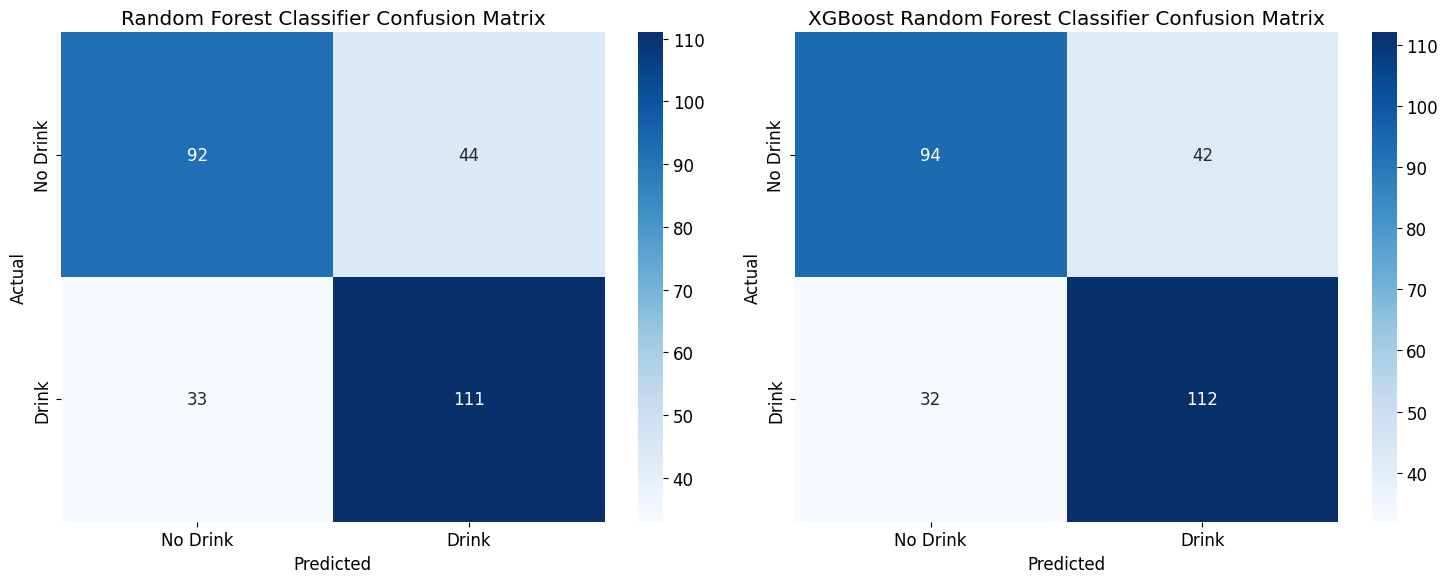

In [25]:
# Create a figure with 1x2 subplots
plt.figure(figsize=(15, 6))

# Plot Random Forest confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.subplot(1, 2, 1)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["No Drink", "Drink"], yticklabels=["No Drink", "Drink"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Classifier Confusion Matrix")

# Plot XGBoost Random Forest confusion matrix
cm_xg_rf = confusion_matrix(y_test, y_pred_xg_rf)
plt.subplot(1, 2, 2)
sns.heatmap(cm_xg_rf, annot=True, fmt="d", cmap="Blues", xticklabels=["No Drink", "Drink"], yticklabels=["No Drink", "Drink"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Random Forest Classifier Confusion Matrix")

plt.tight_layout()
plt.show()


Random Forest ROC AUC: 0.7923
XGBoost Random Forest ROC AUC: 0.8180


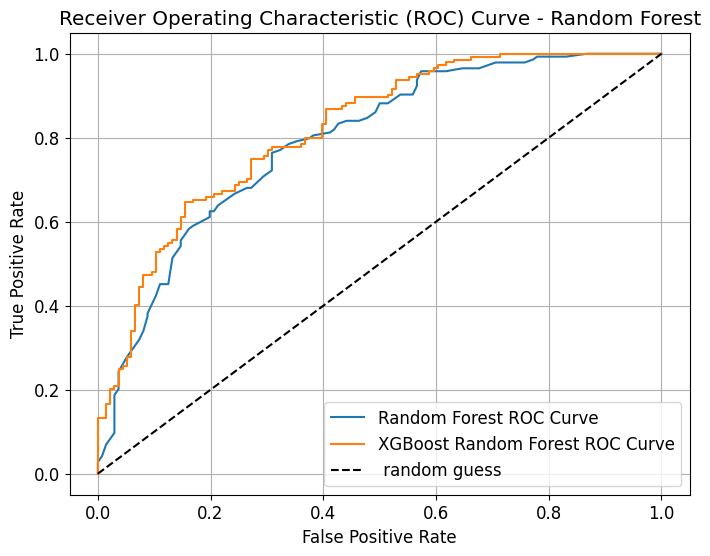

In [26]:
# ROC Curve
y_prob_rf = rf_classifier.predict_proba(X_test)[:, 1]
y_prob_xg_rf = xg_rf_classifier.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
fpr_xg_rf, tpr_xg_rf, thresholds_xg_rf = roc_curve(y_test, y_prob_xg_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest ROC Curve")   
plt.plot(fpr_xg_rf, tpr_xg_rf, label="XGBoost Random Forest ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label=' random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Random Forest')
plt.legend()
plt.grid(True)

# Calculate AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"Random Forest ROC AUC: {roc_auc_rf:.4f}") 
roc_auc_xg_rf = roc_auc_score(y_test, y_prob_xg_rf)
print(f"XGBoost Random Forest ROC AUC: {roc_auc_xg_rf:.4f}")

In [27]:
# Perform cross-validation and create comparison DataFrame
cv_scores_rf = cross_val_score(rf_classifier, X, y, cv=5)
cv_scores_xg_rf = cross_val_score(xg_rf_classifier, X, y, cv=5)

cv_comparison = pd.DataFrame({
     'Random Forest': cv_scores_rf,
     'XGBoost Random Forest': cv_scores_xg_rf
}, index=[f'Fold {i+1}' for i in range(5)])

cv_comparison.loc['Mean'] = [cv_scores_rf.mean(), cv_scores_xg_rf.mean()]
cv_comparison.loc['Std'] = [cv_scores_rf.std(), cv_scores_xg_rf.std()]

display(cv_comparison.round(4))


,Random Forest,XGBoost Random Forest
Fold 1,0.6786,0.6321
Fold 2,0.7000,0.7179
Fold 3,0.6857,0.7071
Fold 4,0.6964,0.7036
Fold 5,0.7036,0.6821
Mean,0.6929,0.6886
Std,0.0093,0.0305


The cross-validation results favor the Random Forest. Its consistent performance suggests it is more likely to generalize well to new, unseen data. The high variance in the XGBoost model's results is a red flag, indicating it might be less dependable in a real-world scenario. The high standard deviation in the cross-validation results for XGBoost is a strong indicator that the model may be overfitting.

C:\Users\rtrin\AppData\Local\Temp\ipykernel_19084\1377695017.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_rf.values, y=feature_importances_rf.index, ax=axes[0], palette="viridis")
C:\Users\rtrin\AppData\Local\Temp\ipykernel_19084\1377695017.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_xg_rf.values, y=feature_importances_xg_rf.index, ax=axes[1], palette="magma")


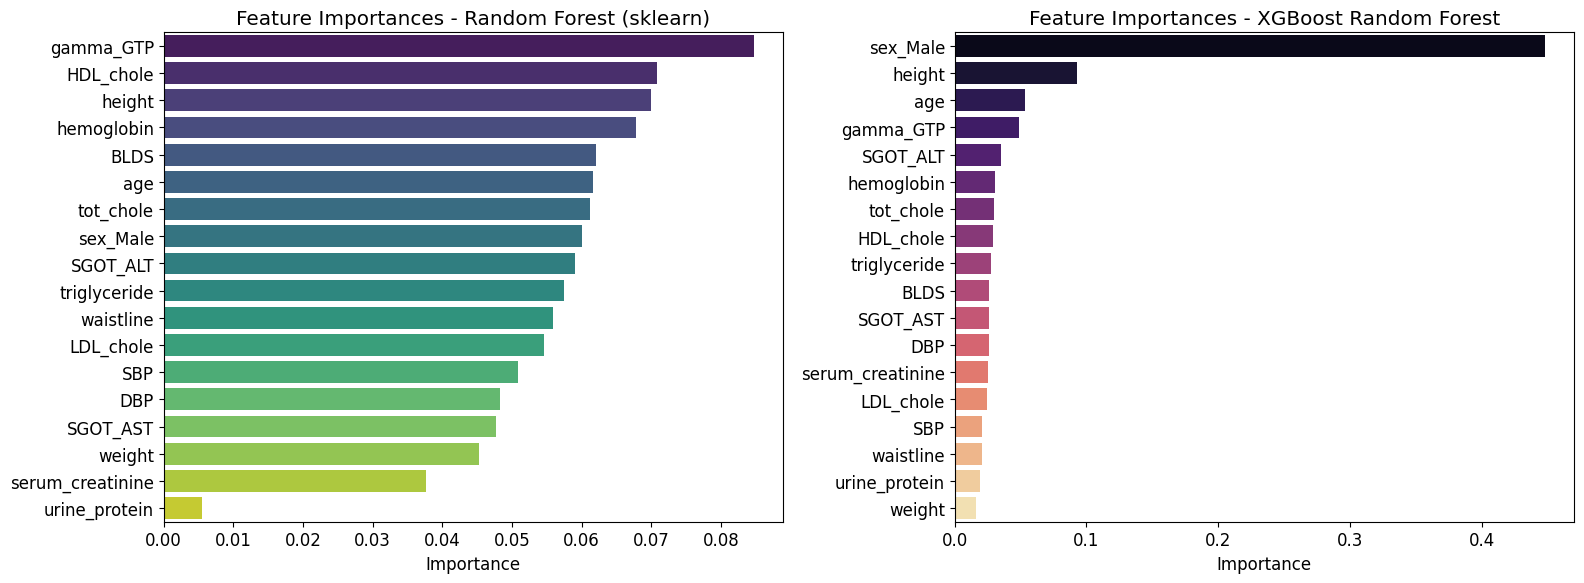

In [28]:
# Prepare feature importance Series (reuse if already defined)
if 'feature_importances_rf' not in globals():
     feature_importances_rf = pd.Series(rf_classifier.feature_importances_, index=X.columns)
feature_importances_rf = feature_importances_rf.sort_values(ascending=False)

if 'feature_importances_xg_rf' not in globals():
     feature_importances_xg_rf = pd.Series(xg_rf_classifier.feature_importances_, index=X.columns)
feature_importances_xg_rf = feature_importances_xg_rf.sort_values(ascending=False)

# Plot them side-by-side (horizontal bars for readability)
fig, axes = plt.subplots(ncols=2, figsize=(16, 6))

sns.barplot(x=feature_importances_rf.values, y=feature_importances_rf.index, ax=axes[0], palette="viridis")
axes[0].set_title('Feature Importances - Random Forest (sklearn)')
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('')

sns.barplot(x=feature_importances_xg_rf.values, y=feature_importances_xg_rf.index, ax=axes[1], palette="magma")
axes[1].set_title('Feature Importances - XGBoost Random Forest')
axes[1].set_xlabel('Importance')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


The two models have drastically different views on which features are important.

- XGBoost is highly focused on a single feature, sex_Male, giving it an overwhelming importance score of around 0.45. Other features like height and age have some influence, but it drops off very quickly. Most features have a negligible importance score.

- Random Forest has a much more balanced and distributed view of feature importance. The importance is spread out more evenly across many features. gamma_GTP is the most important, but many others like HDL_chole, height, and hemoglobin contribute significantly.

Given the previous finding that XGBoost showed high variance in cross-validation, this feature importance plot reinforces the idea that it may have overfit to a pattern involving the sex_Male feature that was present in some data folds but not consistently in others. The Random Forest's more diversified approach appears to be more robust and generalizable.